# Account Intelligence — Exploratory Data Analysis

**Challenge:** help an Account Executive answer *"which accounts should I focus on, and what should I know before my next meeting?"*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/pedrodiogo/Desktop/challenge/data/account_data.csv")
print(f"{df.shape[0]} accounts, {df.shape[1]} columns")
df.head(3)

1000 accounts, 16 columns


,account_id,account_name,account_description,industry,segment,region,nr_employees,days_to_next_renewal,days_since_last_sales_activity,nr_support_tickets,ai_usage,nr_active_users,nr_licensed_seats,current_revenue,call_transcript_summary,revenue_end_of_quarter
0,ACC-0001,Bolt Tech Ventures,Builds developer productivity platforms with i...,Technology,SMB,APAC,53,33,58.0,0,0.584,12,18,9761.87,Expansion conversation initiated by Head of Op...,12610.70
1,ACC-0002,Jade Campus AI,Builds virtual classroom tools with real-time ...,Education,SMB,LATAM,174,143,139.0,11,0.215,7,18,15737.37,"Check-in with VP of Sales. Steady usage, no co...",15737.37
2,ACC-0003,Wave Alloy Dynamics,Manufactures steel structural components for c...,Manufacturing,SMB,NaN,196,183,49.0,3,0.261,5,16,3525.95,Mid-quarter sync. Director of Engineering is h...,3525.95


## Missing values detection

In [2]:
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(1)
pd.DataFrame({"missing": miss, "pct": miss_pct})

,missing,pct
region,402,40.2
call_transcript_summary,52,5.2
ai_usage,30,3.0
days_since_last_sales_activity,20,2.0


In [3]:
# are these missing values random, or tied to the outcome?
df["revenue_delta"] = df["revenue_end_of_quarter"] - df["current_revenue"]
df["revenue_decreased"] = (df["revenue_delta"] < 0).astype(int)

print(f"Revenue decreased: {df['revenue_decreased'].mean():.1%}\n")
for col in miss.index:
    r_missing = df[df[col].isna()]["revenue_decreased"].mean()
    r_present = df[df[col].notna()]["revenue_decreased"].mean()
    print(f"{col:35s}  missing->revenue_decreased {r_missing:.1%}   present->revenue_decreased {r_present:.1%}")

Revenue decreased: 11.0%

region                               missing->revenue_decreased 11.4%   present->revenue_decreased 10.7%
call_transcript_summary              missing->revenue_decreased 19.2%   present->revenue_decreased 10.5%
ai_usage                             missing->revenue_decreased 6.7%   present->revenue_decreased 11.1%
days_since_last_sales_activity       missing->revenue_decreased 5.0%   present->revenue_decreased 11.1%


## Distributions

In [4]:
num_today = [
    "nr_employees", "days_to_next_renewal", "days_since_last_sales_activity",
    "nr_support_tickets", "ai_usage", "nr_active_users", "nr_licensed_seats", "current_revenue",
]
df[num_today].describe().T[["mean", "25%", "50%", "75%", "std", "min", "max"]]

,mean,25%,50%,75%,std,min,max
nr_employees,6145.629000,123.750,733.500,1855.00000,12429.088901,10.00,49974.00
days_to_next_renewal,148.717000,92.000,150.000,208.00000,69.403702,30.00,270.00
days_since_last_sales_activity,63.776531,38.000,62.000,88.00000,36.886487,0.00,180.00
nr_support_tickets,4.198000,2.000,4.000,6.00000,3.091983,0.00,15.00
ai_usage,0.325030,0.093,0.320,0.50875,0.247524,0.00,1.00
nr_active_users,166.010000,16.000,37.000,105.00000,307.848555,1.00,1796.00
nr_licensed_seats,276.580000,31.000,69.000,173.00000,483.397154,5.00,1997.00
current_revenue,246500.572530,13333.610,41937.785,90462.99250,474933.140741,2057.74,1991499.74


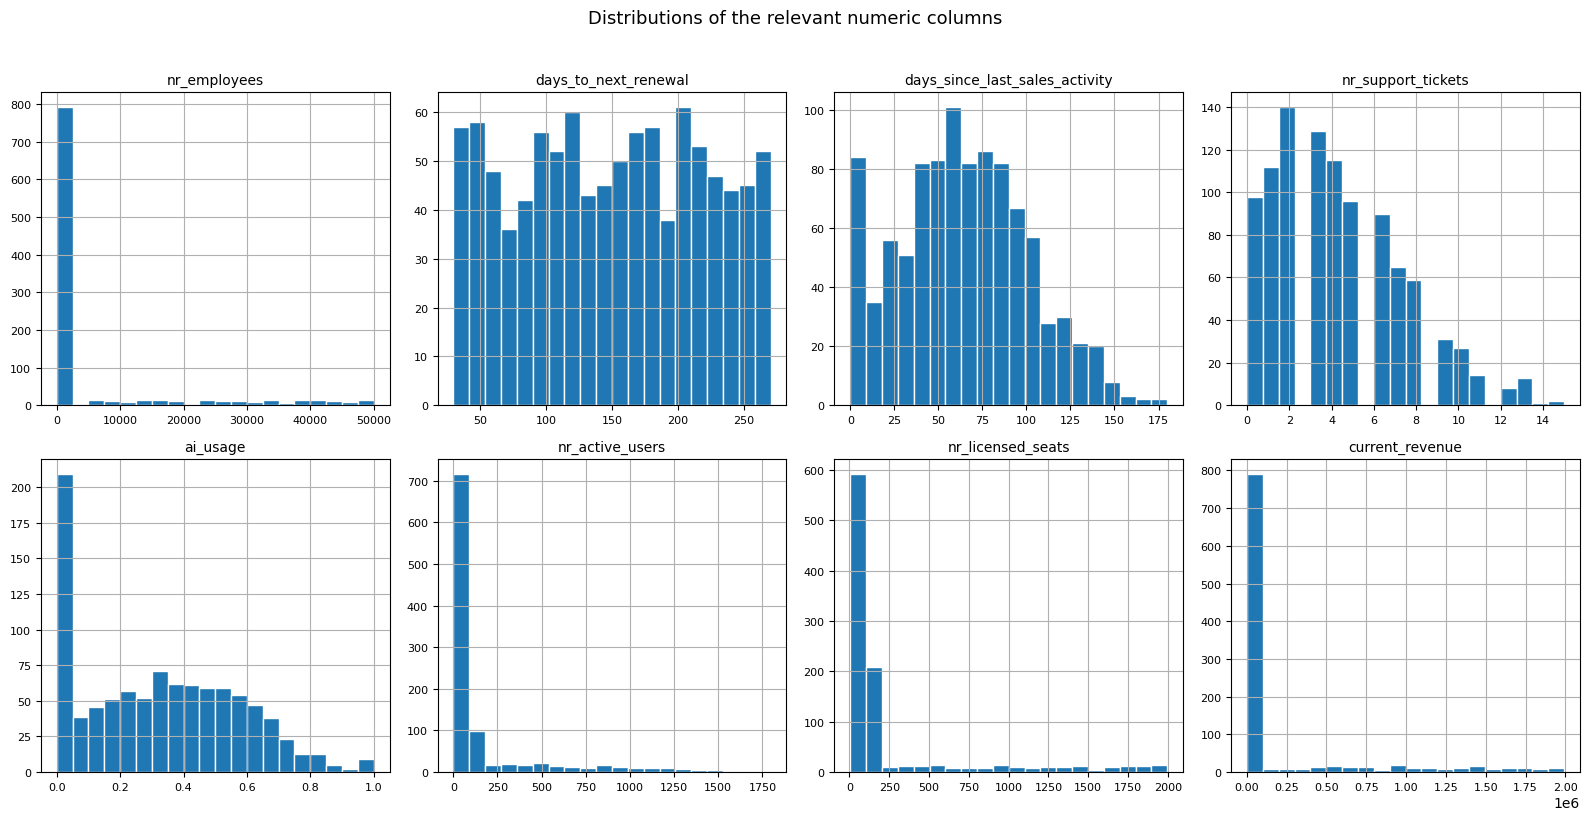

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.ravel(), num_today):
    df[col].hist(bins=20, ax=ax, edgecolor="white")
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)
plt.suptitle("Distributions of the relevant numeric columns", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

nr_active_users, nr_licensed_seats, and current_revenue are all right-skewed, with some outliers

### Output analysis

In [6]:
df["revenue_increased"] = (df["revenue_delta"] > 0).astype(int)

print(f"Revenue maintained: {(df['revenue_delta'] == 0).sum()}")
print(f"Revenue increased: {df['revenue_increased'].sum()} ({df['revenue_increased'].mean():.1%})")
print(
    f"Revenue decreased: {df['revenue_decreased'].sum()} ({df['revenue_decreased'].mean():.1%}) "
    f"-> where {(df['revenue_end_of_quarter'] == 0).sum()} accounts went to zero revenue (churned)"
)

Revenue maintained: 592
Revenue increased: 298 (29.8%)
Revenue decreased: 110 (11.0%) -> where 82 accounts went to zero revenue (churned)


### Correlation analysis

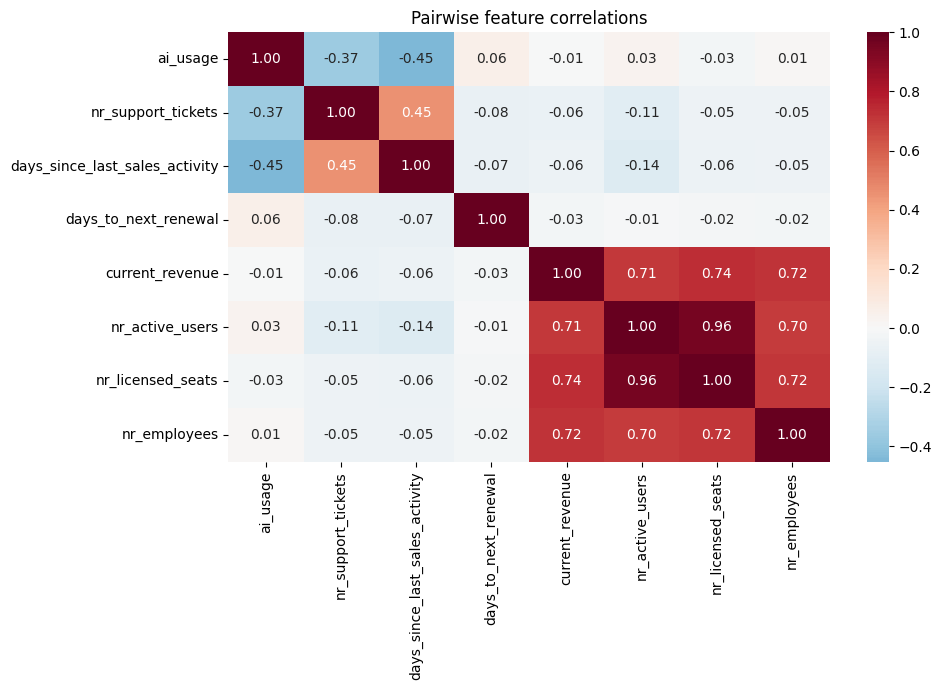

In [7]:
dataset_signals = [
    "ai_usage", "nr_support_tickets", "days_since_last_sales_activity", "days_to_next_renewal",
    "current_revenue", "nr_active_users", "nr_licensed_seats", "nr_employees"
]

df[["days_since_last_sales_activity"]].rank(pct=True)
fig, ax = plt.subplots(figsize=(10, 7))
corr = df[dataset_signals].corr()

sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, fmt=".2f", ax=ax)
ax.set_title("Pairwise feature correlations")
plt.tight_layout()
plt.show()

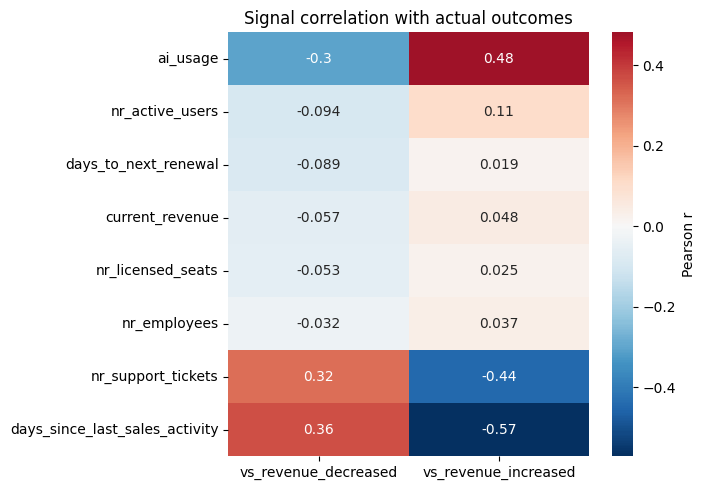

In [8]:
corr = pd.DataFrame({
    "vs_revenue_decreased": df[dataset_signals + ["revenue_decreased"]].corr(numeric_only=True)["revenue_decreased"].drop("revenue_decreased"),
    "vs_revenue_increased": df[dataset_signals + ["revenue_increased"]].corr(numeric_only=True)["revenue_increased"].drop("revenue_increased"),
}).round(3).sort_values("vs_revenue_decreased")

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("Signal correlation with actual outcomes")
plt.tight_layout()
plt.show()

## Engineered features (possible 'signals')

In [9]:
df["seat_utilization"] = df["nr_active_users"] / df["nr_licensed_seats"]
df["tickets_per_active_user"] = df["nr_support_tickets"] / df["nr_active_users"]
df["no_recent_call"] = df["call_transcript_summary"].isna().astype(int)

new_signals = ["seat_utilization", "tickets_per_active_user", "no_recent_call"]

all_signals = dataset_signals + new_signals
df[new_signals].describe().T[["mean", "25%", "50%", "75%", "min", "max"]]

,mean,25%,50%,75%,min,max
seat_utilization,0.569901,0.440762,0.576826,0.699748,0.007353,1.0
tickets_per_active_user,0.315300,0.012619,0.076923,0.272727,0.000000,10.0
no_recent_call,0.052000,0.000000,0.000000,0.000000,0.000000,1.0


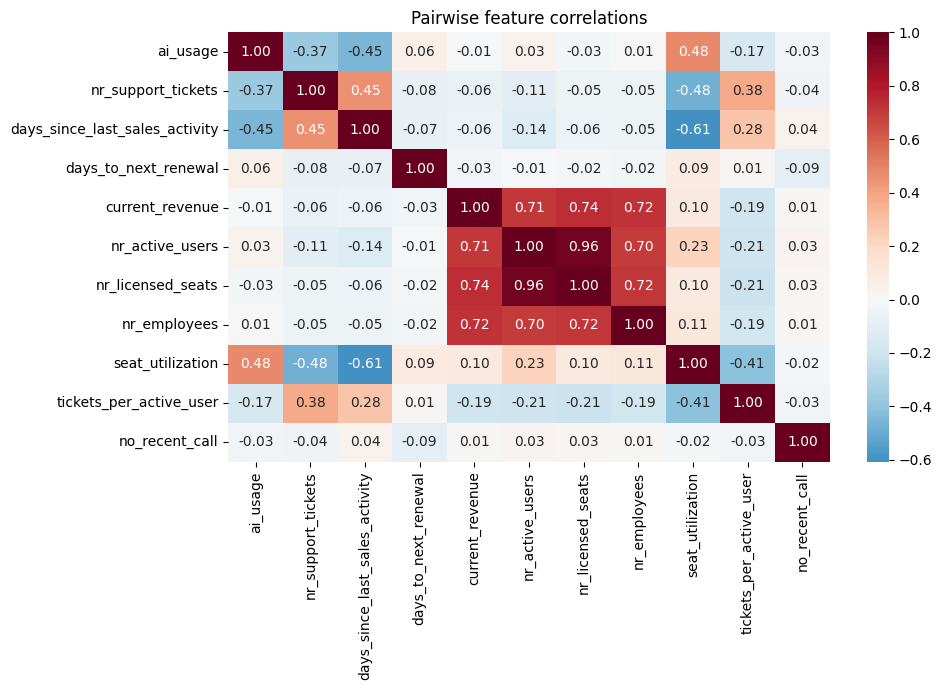

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))
corr = df[all_signals].corr()

sns.heatmap(corr, annot=True, cmap="RdBu_r",
            center=0, fmt=".2f", ax=ax)
ax.set_title("Pairwise feature correlations")
plt.tight_layout()
plt.show()

Signals with correlation > 0.3 with either revenue decrease or increase:
['seat_utilization', 'ai_usage', 'nr_support_tickets', 'days_since_last_sales_activity']


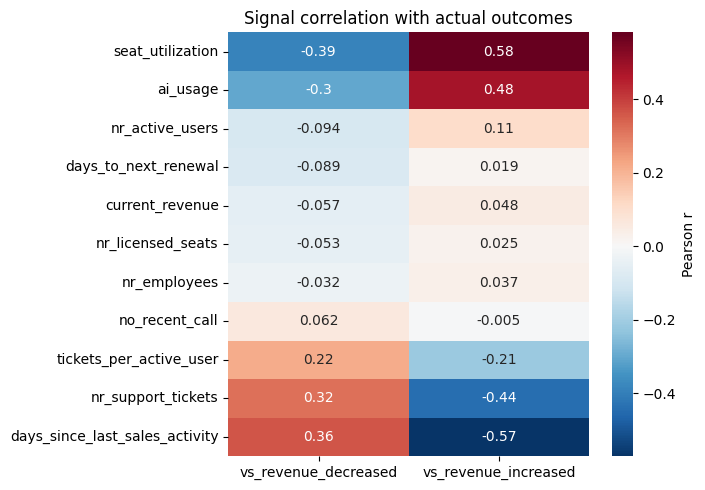

In [11]:
corr = pd.DataFrame({
    "vs_revenue_decreased": df[all_signals + ["revenue_decreased"]].corr(numeric_only=True)["revenue_decreased"].drop("revenue_decreased"),
    "vs_revenue_increased": df[all_signals + ["revenue_increased"]].corr(numeric_only=True)["revenue_increased"].drop("revenue_increased"),
}).round(3).sort_values("vs_revenue_decreased")

relevant_signals = corr[
    (corr["vs_revenue_decreased"].abs() > 0.3) | (corr["vs_revenue_increased"].abs() > 0.3)
].index.tolist()
print("Signals with correlation > 0.3 with either revenue decrease or increase:")
print(relevant_signals)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("Signal correlation with actual outcomes")
plt.tight_layout()
plt.show()

### Seat utilization analysis

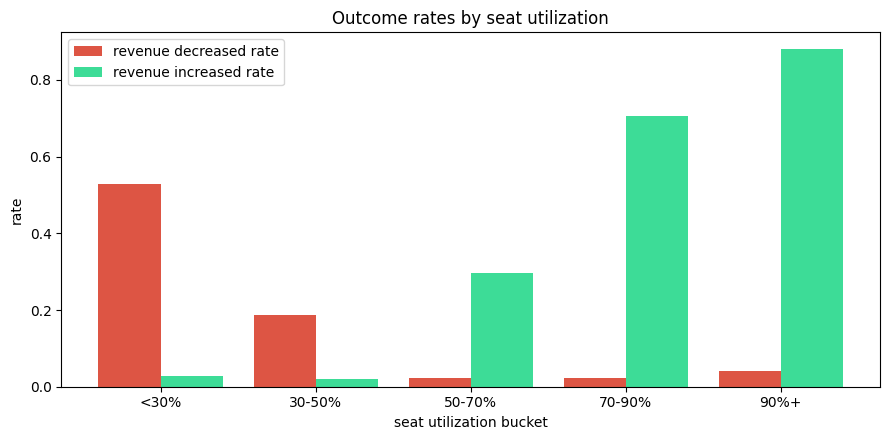

In [12]:
df["seat_utilization_bin"] = pd.cut(
    df["seat_utilization"],
    [0, 0.3, 0.5, 0.7, 0.9, 1.01],
    labels=["<30%", "30-50%", "50-70%", "70-90%", "90%+"]
)

tbl = df.groupby("seat_utilization_bin", observed=True).agg(
    accounts=("account_id", "count"),
    revenue_decreased_rate=("revenue_decreased", "mean"),
    revenue_increased_rate=("revenue_increased", "mean"),
).round(3)

fig, ax = plt.subplots(figsize=(9,4.5))
x = range(len(tbl))
ax.bar([i - 0.2 for i in x], tbl["revenue_decreased_rate"], width=0.4, label="revenue decreased rate", color="#dd5544")
ax.bar([i + 0.2 for i in x], tbl["revenue_increased_rate"], width=0.4, label="revenue increased rate", color="#3ddc97")
ax.set_xticks(list(x)); ax.set_xticklabels(tbl.index)
ax.set_ylabel("rate"); ax.set_xlabel("seat utilization bucket")
ax.set_title("Outcome rates by seat utilization")
ax.legend()
plt.tight_layout()
plt.show()

Below 30% seat utilization, revenue decreased rate is **53%**; above 50%, it drops to ~2%. Revenue increased rate mirrors this behavior, climbing from 3% to **88%** at the top.

## Does the call summary transcript be potentially useful?

I know this is just a synthetic dataset and the transcripts were probably generated from the outcome but it seems like the call summary transcript column could contain a lot of valuable information. We could try explore first a more rudimentary approach like keyword search (e.g. look for words like "dissatisfied", "competitor", "budget", etc), and then potentially use an llm to extract more structured signals (e.g. "churn risk level: high/medium/low", "competitor mentioned: yes/no", "expansion intention: yes/no", etc, etc) -> example of this: `TranscriptParserAgent` in `src/agents/transcript_parser.py`

t_competitor      14
t_frustration    108
t_expansion      226
dtype: int64

Revenue decreased rate: 11.0%
   transcript mentions competitor -> revenue decreased 100.0% (n=14)
   transcript mentions frustration -> revenue decreased 39.8% (n=108)

Revenue increased rate: 29.8%
   transcript mentions expansion -> revenue increased 81.9%  (n=226)


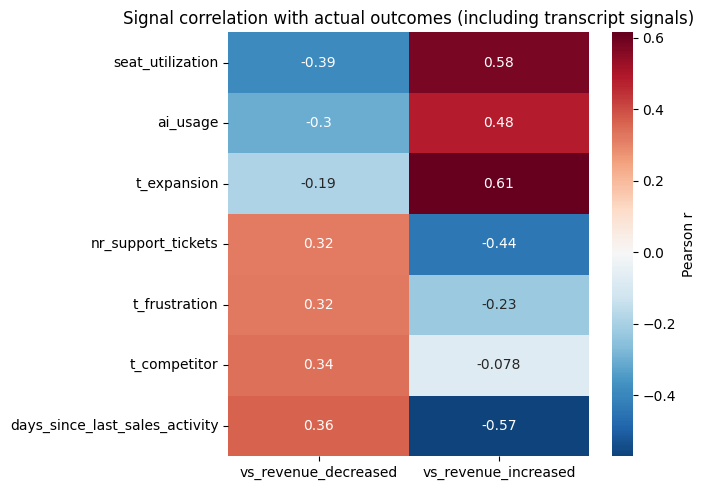

In [13]:
txt = df["call_transcript_summary"].fillna("").str.lower()
df["t_competitor"] = txt.str.contains("competitor|replace|evaluating|switch").astype(int)
df["t_frustration"] = txt.str.contains("frustrat|delay|complain|escalat|unhappy|concern|disappoint").astype(int)
df["t_expansion"] = txt.str.contains("seat|expand|upsell|additional|roll out|rollout|fast-track").astype(int)


print(df[["t_competitor", "t_frustration", "t_expansion"]].sum())
print()
print(f"Revenue decreased rate: {df['revenue_decreased'].mean():.1%}")
print(f"{'':3s}transcript mentions competitor -> revenue decreased {df[df.t_competitor==1]['revenue_decreased'].mean():.1%} (n={df.t_competitor.sum()})")
print(f"{'':3s}transcript mentions frustration -> revenue decreased {df[df.t_frustration==1]['revenue_decreased'].mean():.1%} (n={df.t_frustration.sum()})")
print()
print(f"Revenue increased rate: {df['revenue_increased'].mean():.1%}")
print(f"{'':3s}transcript mentions expansion -> revenue increased {df[df.t_expansion==1]['revenue_increased'].mean():.1%}  (n={df.t_expansion.sum()})")


corr = pd.DataFrame({
    "vs_revenue_decreased": df[relevant_signals + ["t_competitor", "t_frustration", "t_expansion", "revenue_decreased"]].corr(numeric_only=True)["revenue_decreased"].drop("revenue_decreased"),
    "vs_revenue_increased": df[relevant_signals + ["t_competitor", "t_frustration", "t_expansion", "revenue_increased"]].corr(numeric_only=True)["revenue_increased"].drop("revenue_increased"),
}).round(3).sort_values("vs_revenue_decreased")

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("Signal correlation with actual outcomes (including transcript signals)")
plt.tight_layout()
plt.show()

## Segment & industry context

In [14]:
seg = df.groupby("segment").agg(
    accounts=("account_id", "count"),
    avg_revenue=("current_revenue", "mean"),
    median_revenue=("current_revenue", "median"),
    revenue_75_pct=("current_revenue", lambda x: x.quantile(0.75)),
    avg_util=("seat_utilization", "mean"),
    revenue_decreased_rate=("revenue_decreased", "mean"),
    revenue_increased_rate=("revenue_increased", "mean")
).round(3)

seg

,accounts,avg_revenue,median_revenue,revenue_75_pct,avg_util,revenue_decreased_rate,revenue_increased_rate
segment,,,,,,,
Enterprise,210,1040548.919,1025568.765,1450533.245,0.609,0.076,0.343
Mid-Market,395,59124.815,59038.090,78120.675,0.579,0.104,0.286
SMB,395,11724.044,10834.970,15739.425,0.540,0.134,0.286


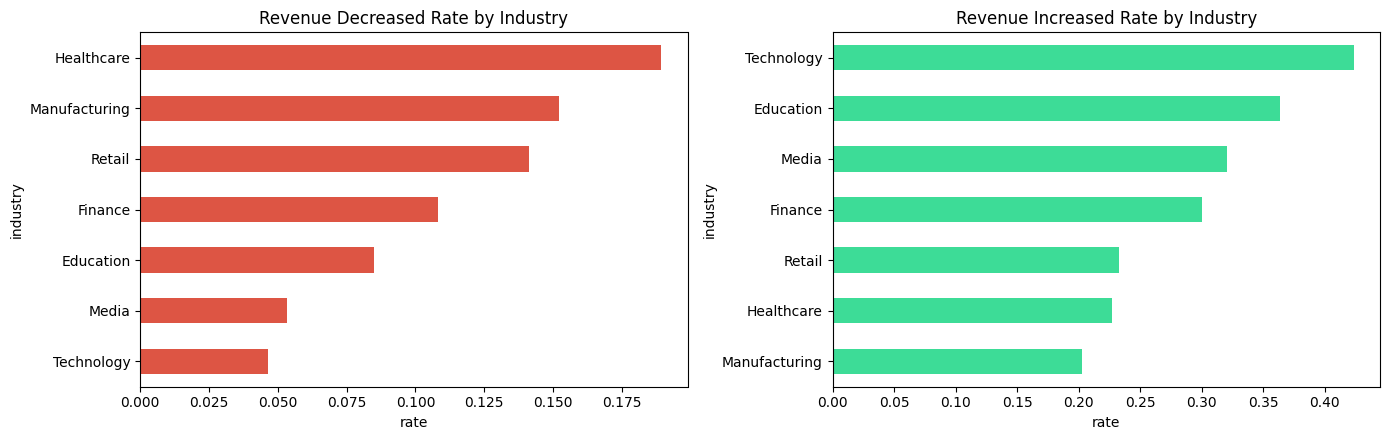

In [15]:
fig, axes = plt.subplots(1,2, figsize=(14,4.5))
df.groupby("industry")["revenue_decreased"].mean().sort_values().plot.barh(ax=axes[0], color="#dd5544")
axes[0].set_title("Revenue Decreased Rate by Industry"); axes[0].set_xlabel("rate")
df.groupby("industry")["revenue_increased"].mean().sort_values().plot.barh(ax=axes[1], color="#3ddc97")
axes[1].set_title("Revenue Increased Rate by Industry"); axes[1].set_xlabel("rate")
plt.tight_layout(); plt.show()

### Scores creation

In [16]:
df["days_since_last_sales_activity"] = df["days_since_last_sales_activity"].fillna(
    df["days_since_last_sales_activity"].median()
)
df["ai_usage"] = df["ai_usage"].fillna(df["ai_usage"].median())

df["activity_norm"] = df["days_since_last_sales_activity"].rank(pct=True)
df["tickets_norm"] = df["nr_support_tickets"].rank(pct=True)

w_churn = {"util": 0.35, "activity": 0.30, "tickets": 0.20, "ai": 0.15}

df["churn_risk_score"] = (
    w_churn["util"] * (1 - df["seat_utilization"])
  + w_churn["activity"] * df["activity_norm"]
  + w_churn["tickets"] * df["tickets_norm"]
  + w_churn["ai"] * (1 - df["ai_usage"])
)

w_expansion = {"util": 0.30, "activity": 0.30, "tickets": 0.25, "ai": 0.15}
df["expansion_score"] = (
  w_expansion["util"] * df["seat_utilization"]
  + w_expansion["activity"] * (1 - df["activity_norm"])
  + w_expansion["tickets"] * (1 - df["tickets_norm"])
  + w_expansion["ai"] * df["ai_usage"]
)

df["churn_nudge"] = (
    0.15 * df["t_competitor"]
  + 0.10 * df["t_frustration"]
)
df["expansion_nudge"] = 0.10 * df["t_expansion"]

df["churn_risk_score"] = (df["churn_risk_score"] + df["churn_nudge"]).clip(0, 1)
df["expansion_score"] = (df["expansion_score"] + df["expansion_nudge"]).clip(0, 1)

top = df[df.churn_risk_score >= df.churn_risk_score.quantile(0.9)]["revenue_decreased"].mean()
bot = df[df.churn_risk_score <= df.churn_risk_score.quantile(0.1)]["revenue_decreased"].mean()
print(f"Top-decile churn rate: {top:.1%} | bottom-decile: {bot:.1%}")

top = df[df.expansion_score >= df.expansion_score.quantile(0.9)]["revenue_increased"].mean()
bot = df[df.expansion_score <= df.expansion_score.quantile(0.1)]["revenue_increased"].mean()
print(f"Top-decile expansion rate: {top:.1%} | bottom-decile: {bot:.1%}")


Top-decile churn rate: 64.0% | bottom-decile: 2.0%
Top-decile expansion rate: 99.0% | bottom-decile: 1.0%


In [17]:
df["action_score"] = df[["churn_risk_score", "expansion_score"]].max(axis=1)

df["revenue_norm"] = df["current_revenue"].rank(pct=True)

df["urgency"] = 1 - df["days_to_next_renewal"].rank(pct=True)

df["priority_score"] = (df["revenue_norm"] * df["urgency"]  * df["action_score"])
assert df["priority_score"].notna().all()
df = df.sort_values("priority_score", ascending=False)

In [18]:
df.head(10)[["account_name", "segment", "current_revenue",
             "days_to_next_renewal", "days_since_last_sales_activity", "churn_risk_score",
             "expansion_score", "priority_score"]]

,account_name,segment,current_revenue,days_to_next_renewal,days_since_last_sales_activity,churn_risk_score,expansion_score,priority_score
932,Vivid Gene Studio,Enterprise,1440902.30,40,140.0,1.000000,0.146714,0.898230
705,Bolt Brand AI,Enterprise,1656859.06,40,0.0,0.178009,0.924717,0.847273
471,Zeta Edu AI,Enterprise,464653.15,34,33.0,0.164963,0.938214,0.756998
840,Vertex Ledger AI,Enterprise,1597616.18,41,0.0,0.191794,0.827216,0.750437
695,Sync Care Studio,Enterprise,1307315.62,50,104.0,0.881544,0.202727,0.737515
261,Xenon Bio Ventures,Enterprise,1780578.48,54,29.0,0.268087,0.844036,0.730709
606,Beta Fund Global,Enterprise,1821995.06,59,35.0,0.256351,0.841281,0.710479
623,Orbit Equity Systems,Enterprise,1514827.33,33,6.0,0.378249,0.718815,0.675828
310,Vertex Craft Co,Enterprise,205244.92,32,141.0,0.851817,0.148932,0.675320
15,Rapid Campus Ventures,Enterprise,1962024.03,40,71.0,0.697652,0.280862,0.660400
